  trader_id age_group experience_level  starting_capital  ending_balance  \
0   TR00001     36-45     Intermediate            212049          211384   
1   TR00002     18-25         Beginner             59115           39272   
2   TR00003     26-35         Beginner             98223           82133   
3   TR00004     26-35     Intermediate            241962          253262   
4   TR00005     36-45         Beginner             76387           62307   

   monthly_return_pct  max_drawdown_pct  position_size_pct  win_ratio  \
0               -0.33              1.99               5.11       0.47   
1              -34.28             33.39              49.00       0.20   
2              -15.79             23.46              29.63       0.26   
3                4.39              8.96              19.46       0.48   
4              -18.74             30.40              42.83       0.23   

   risk_reward_ratio  trades_per_week  avg_holding_period_days  \
0               0.84               11 

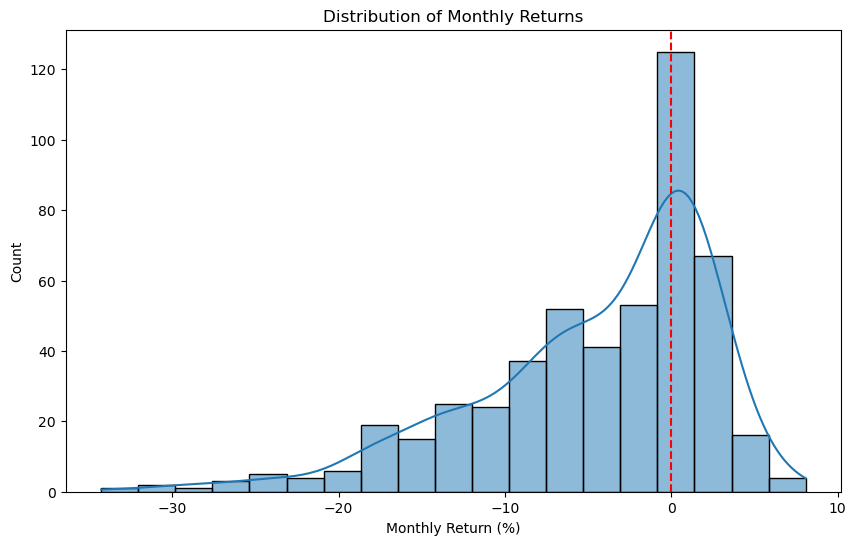

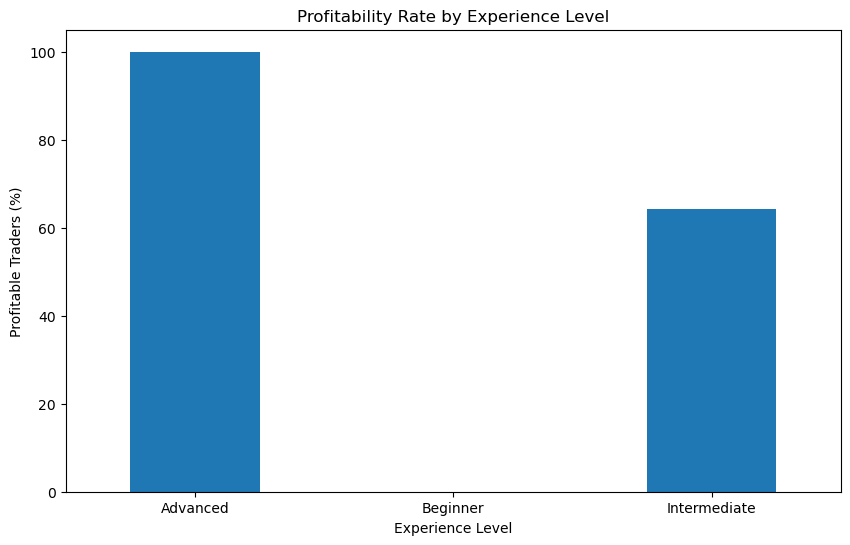

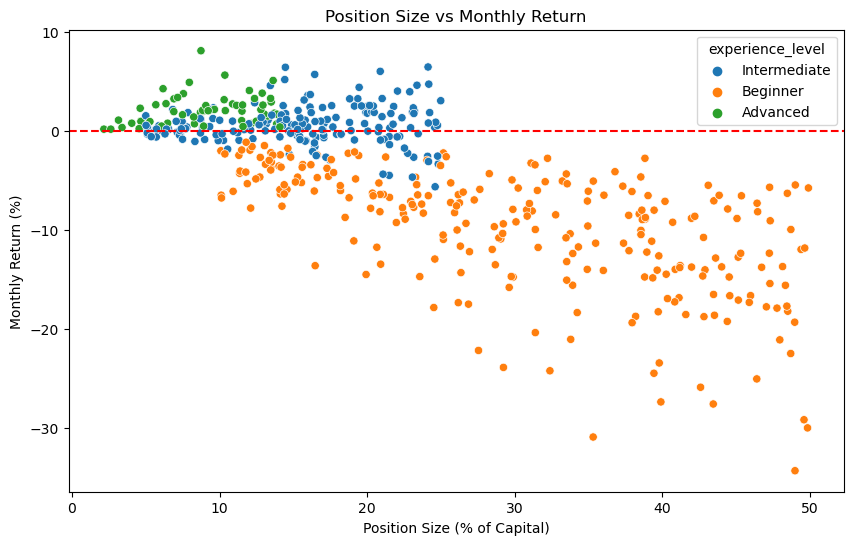

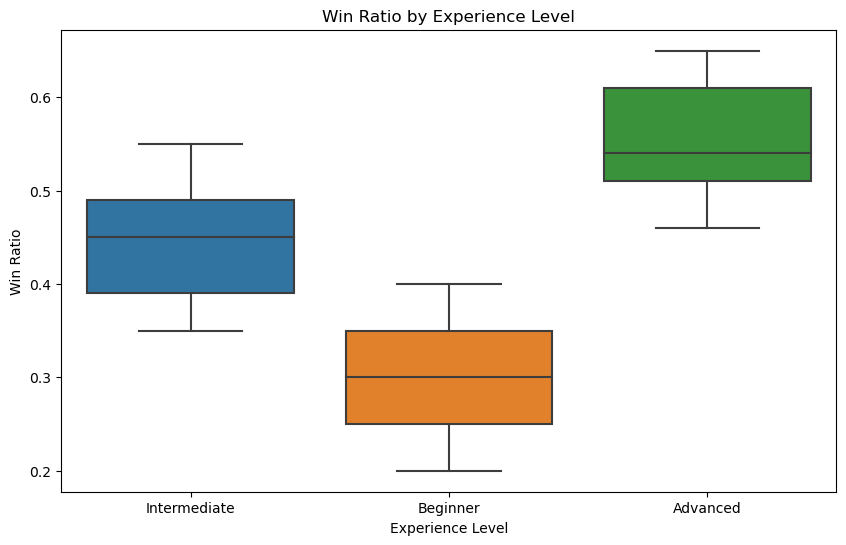

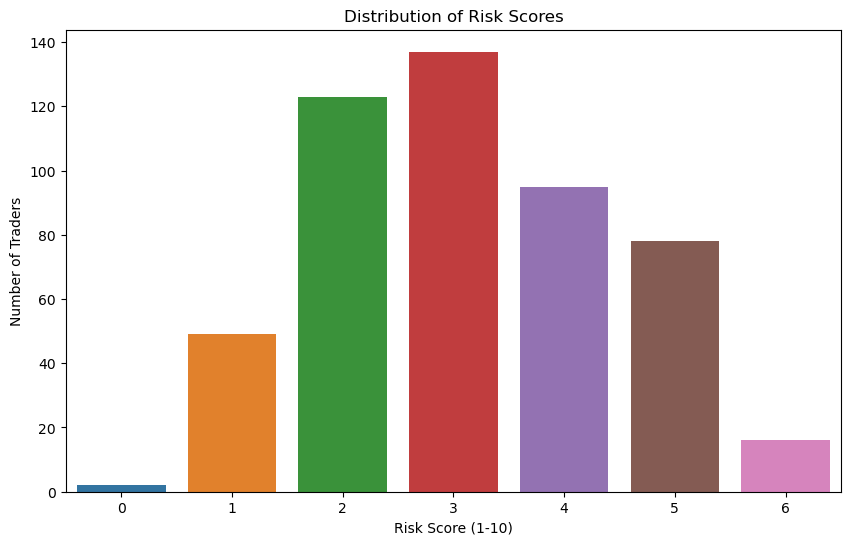

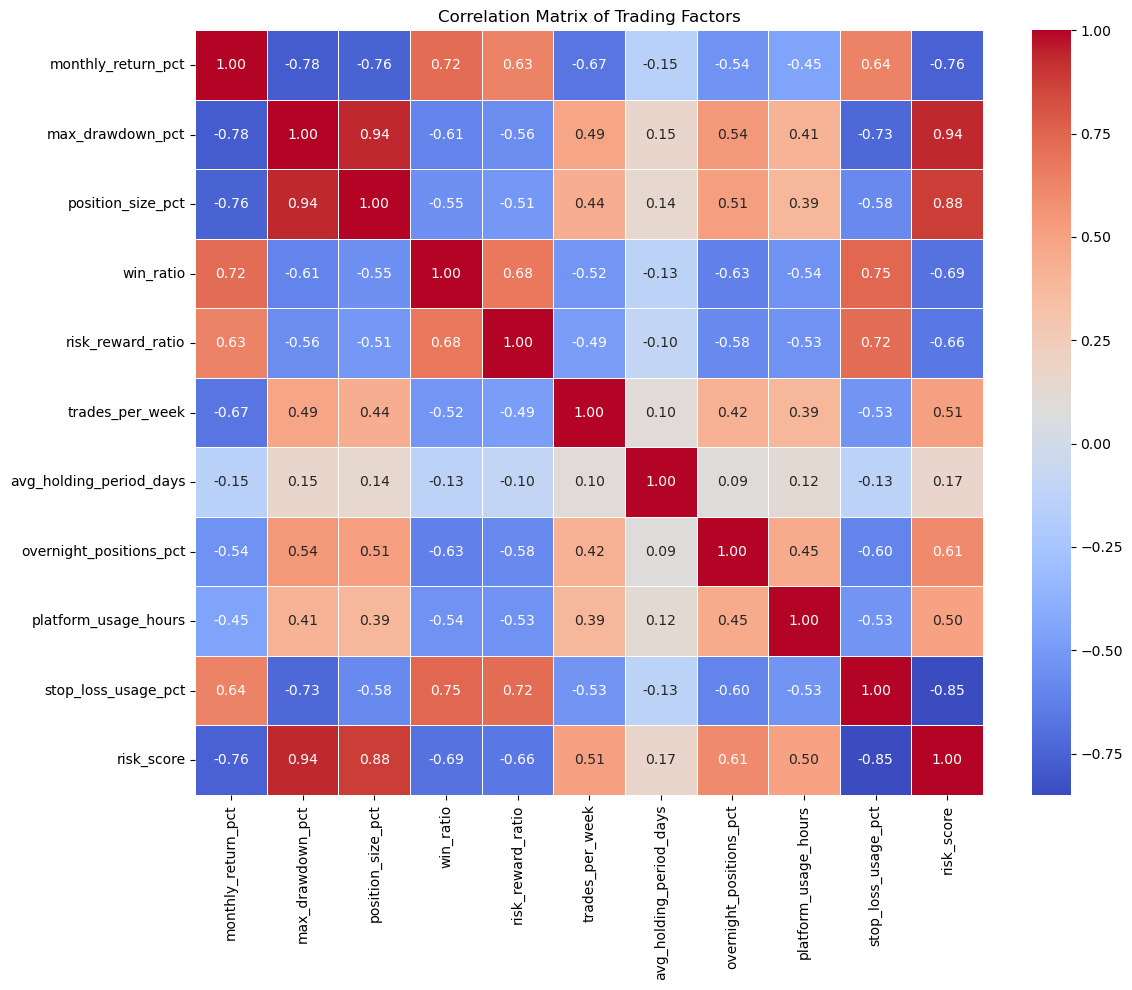

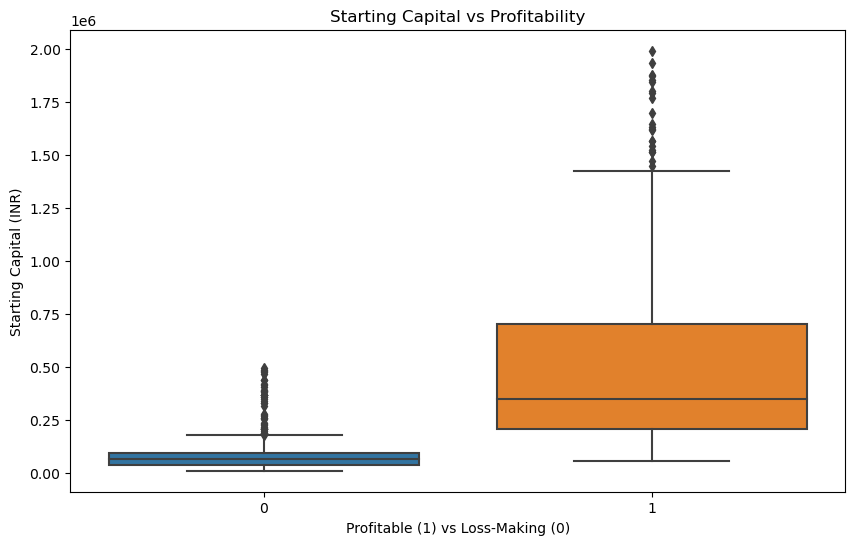

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
from sklearn.preprocessing import MinMaxScaler

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Create a function to generate synthetic trader data
def generate_trader_dataset(n_traders=500):
    """
    Generate synthetic trader data based on patterns observed in SEBI and NSE reports.
    
    Parameters:
    -----------
    n_traders : int
        Number of traders to generate
        
    Returns:
    --------
    pandas.DataFrame
        Synthetic dataset of traders
    """
    # Generate trader IDs
    trader_ids = [f"TR{str(i).zfill(5)}" for i in range(1, n_traders + 1)]
    
    # Generate demographic data
    # Age distribution based on NSE retail investor profile
    age_groups = ["18-25", "26-35", "36-45", "46-55", "56+"]
    age_weights = [0.15, 0.35, 0.25, 0.15, 0.10]  # Higher weight for 26-35 age group
    ages = random.choices(age_groups, weights=age_weights, k=n_traders)
    
    # Experience levels
    experience_levels = ["Beginner", "Intermediate", "Advanced"]
    experience_weights = [0.55, 0.35, 0.10]  # Higher weight for beginners as per SEBI reports
    experience = random.choices(experience_levels, weights=experience_weights, k=n_traders)
    
    # Trading frequency per week
    # SEBI reports suggest most retail traders trade very frequently
    trading_frequency = []
    for exp in experience:
        if exp == "Beginner":
            trading_frequency.append(np.random.randint(10, 30))  # Beginners often overtrade
        elif exp == "Intermediate":
            trading_frequency.append(np.random.randint(5, 20))
        else:
            trading_frequency.append(np.random.randint(2, 15))  # Advanced traders often trade less

    # Starting capital (in INR)
    # SEBI data suggests most retail traders start with small capital
    starting_capital = []
    for exp in experience:
        if exp == "Beginner":
            # Most beginners start with small capital (₹10,000 - ₹100,000)
            starting_capital.append(np.random.randint(10000, 100000))
        elif exp == "Intermediate":
            starting_capital.append(np.random.randint(50000, 500000))
        else:
            starting_capital.append(np.random.randint(200000, 2000000))
            
    # Generate trading behaviors
    
    # Position sizing (as % of capital)
    position_sizing = []
    for exp in experience:
        if exp == "Beginner":
            # Beginners often size positions too large
            position_sizing.append(np.random.uniform(10, 50))
        elif exp == "Intermediate":
            position_sizing.append(np.random.uniform(5, 25))
        else:
            position_sizing.append(np.random.uniform(2, 15))
    
    # Holding period (in days)
    holding_period = []
    for exp in experience:
        if exp == "Beginner":
            # Beginners often don't hold positions long enough or hold too long
            choices = [np.random.uniform(0.1, 1), np.random.uniform(10, 30)]
            holding_period.append(random.choice(choices))
        elif exp == "Intermediate":
            holding_period.append(np.random.uniform(1, 10))
        else:
            holding_period.append(np.random.uniform(3, 15))
    
    # Win ratio (wins / total trades)
    win_ratio = []
    for exp in experience:
        if exp == "Beginner":
            # Beginners typically have lower win ratios
            win_ratio.append(np.random.uniform(0.2, 0.4))
        elif exp == "Intermediate":
            win_ratio.append(np.random.uniform(0.35, 0.55))
        else:
            win_ratio.append(np.random.uniform(0.45, 0.65))
    
    # Risk-reward ratio
    risk_reward = []
    for exp in experience:
        if exp == "Beginner":
            # Beginners often have poor risk-reward
            risk_reward.append(np.random.uniform(0.5, 1.2))
        elif exp == "Intermediate":
            risk_reward.append(np.random.uniform(0.8, 2.0))
        else:
            risk_reward.append(np.random.uniform(1.5, 3.0))
    
    # Overnight positions (% of trades held overnight)
    overnight_positions = []
    for exp in experience:
        if exp == "Beginner":
            # Beginners often hold overnight due to hope
            overnight_positions.append(np.random.uniform(30, 80))
        elif exp == "Intermediate":
            overnight_positions.append(np.random.uniform(20, 50))
        else:
            overnight_positions.append(np.random.uniform(10, 40))
    
    # Platform usage time (hours per day)
    platform_usage = []
    for exp in experience:
        if exp == "Beginner":
            # Beginners often spend too much time watching markets
            platform_usage.append(np.random.uniform(3, 8))
        elif exp == "Intermediate":
            platform_usage.append(np.random.uniform(2, 6))
        else:
            platform_usage.append(np.random.uniform(1, 4))
    
    # Trading type preferences
    trading_types = ["Intraday", "Swing", "Positional", "Mixed"]
    trading_type_weights = [0.45, 0.25, 0.15, 0.15]  # Higher weight for intraday as per NSE data
    preferred_trading_type = random.choices(trading_types, weights=trading_type_weights, k=n_traders)
    
    # Instrument preferences
    instruments = ["Equity", "F&O", "Currency", "Commodities", "Mixed"]
    instrument_weights = [0.30, 0.40, 0.10, 0.05, 0.15]  # Higher weight for F&O as per SEBI data
    preferred_instruments = random.choices(instruments, weights=instrument_weights, k=n_traders)
    
    # Trade decisions based on
    decision_factors = ["Technical Analysis", "Fundamental Analysis", "News Events", "Tips/Recommendations", "Mixed"]
    decision_weights = [0.35, 0.15, 0.10, 0.25, 0.15]  # Higher weight for technical and tips
    trade_decisions = random.choices(decision_factors, weights=decision_weights, k=n_traders)
    
    # Stop loss usage
    stop_loss_usage = []
    for exp in experience:
        if exp == "Beginner":
            # Many beginners don't use stop losses
            stop_loss_usage.append(np.random.uniform(10, 40))
        elif exp == "Intermediate":
            stop_loss_usage.append(np.random.uniform(30, 70))
        else:
            stop_loss_usage.append(np.random.uniform(60, 95))
    
    # Calculate performance metrics
    
    # Monthly return (%)
    monthly_return = []
    for i in range(n_traders):
        # Calculate based on win ratio, risk-reward, and position sizing
        win_r = win_ratio[i]
        rr = risk_reward[i]
        pos_size = position_sizing[i] / 100
        
        # Expected value per trade = (Win% * Win Amount) - (Loss% * Loss Amount)
        # Assuming 1R loss for simplicity
        expected_value = (win_r * rr) - (1 - win_r)
        
        # Monthly return based on trading frequency and expected value
        trades_per_month = trading_frequency[i] * 4
        
        # Add randomness to simulate real-world variance
        variance_factor = np.random.uniform(0.7, 1.3)
        
        monthly_return.append(trades_per_month * expected_value * pos_size * variance_factor)
    
    # Max drawdown (%)
    max_drawdown = []
    for i in range(n_traders):
        # Higher position sizing and lower stop loss usage leads to higher drawdowns
        base_drawdown = position_sizing[i] * (1 - (stop_loss_usage[i]/100)) * np.random.uniform(0.8, 1.2)
        max_drawdown.append(min(base_drawdown, 100))  # Cap at 100%
    
    # Profit/Loss status
    is_profitable = [1 if ret > 0 else 0 for ret in monthly_return]
    
    # Account balance change (%)
    balance_change = []
    for ret in monthly_return:
        # Add some variance to make it more realistic
        balance_change.append(ret * np.random.uniform(0.9, 1.1))
    
    # Calculate actual ending balance
    ending_balance = [start_cap * (1 + (chg/100)) for start_cap, chg in zip(starting_capital, balance_change)]
    
    # Create risk score (1-10, higher is riskier)
    # Based on position sizing, stop loss usage, and drawdown
    risk_score = []
    for i in range(n_traders):
        score = (
            (position_sizing[i] / 10) * 0.4 + 
            ((100 - stop_loss_usage[i]) / 10) * 0.3 + 
            (max_drawdown[i] / 10) * 0.3
        )
        risk_score.append(min(round(score), 10))  # Cap at 10
    
    # Create the dataframe
    trader_data = pd.DataFrame({
        'trader_id': trader_ids,
        'age_group': ages,
        'experience_level': experience,
        'starting_capital': starting_capital,
        'ending_balance': [round(val) for val in ending_balance],
        'monthly_return_pct': [round(val, 2) for val in monthly_return],
        'max_drawdown_pct': [round(val, 2) for val in max_drawdown],
        'position_size_pct': [round(val, 2) for val in position_sizing],
        'win_ratio': [round(val, 2) for val in win_ratio],
        'risk_reward_ratio': [round(val, 2) for val in risk_reward],
        'trades_per_week': trading_frequency,
        'avg_holding_period_days': [round(val, 2) for val in holding_period],
        'overnight_positions_pct': [round(val, 2) for val in overnight_positions],
        'platform_usage_hours': [round(val, 2) for val in platform_usage],
        'preferred_trading_type': preferred_trading_type,
        'preferred_instruments': preferred_instruments,
        'trade_decision_factor': trade_decisions,
        'stop_loss_usage_pct': [round(val, 2) for val in stop_loss_usage],
        'is_profitable': is_profitable,
        'risk_score': risk_score
    })
    
    return trader_data

# Generate the dataset
traders_df = generate_trader_dataset(500)

# Display the first few rows
print(traders_df.head())

# Generate summary statistics
print("\nSummary Statistics:")
print(traders_df.describe())

# Calculate profitability rate
profitable_percent = traders_df['is_profitable'].mean() * 100
print(f"\nProfitable Traders: {profitable_percent:.2f}%")
print(f"Loss-Making Traders: {100 - profitable_percent:.2f}%")

# Save to CSV
traders_df.to_csv('india_retail_traders_synthetic_data.csv', index=False)
print("\nDataset saved to 'india_retail_traders_synthetic_data.csv'")

# Additional insights based on SEBI and NSE patterns

# 1. Monthly Return Distribution
plt.figure(figsize=(10, 6))
sns.histplot(traders_df['monthly_return_pct'], kde=True)
plt.title('Distribution of Monthly Returns')
plt.xlabel('Monthly Return (%)')
plt.axvline(x=0, color='red', linestyle='--')
plt.savefig('monthly_returns_distribution.png')

# 2. Profitability by Experience Level
plt.figure(figsize=(10, 6))
exp_profit = traders_df.groupby('experience_level')['is_profitable'].mean() * 100
exp_profit.plot(kind='bar')
plt.title('Profitability Rate by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Profitable Traders (%)')
plt.xticks(rotation=0)
plt.savefig('profitability_by_experience.png')

# 3. Position Size vs Return
plt.figure(figsize=(10, 6))
sns.scatterplot(x='position_size_pct', y='monthly_return_pct', 
                hue='experience_level', data=traders_df)
plt.title('Position Size vs Monthly Return')
plt.xlabel('Position Size (% of Capital)')
plt.ylabel('Monthly Return (%)')
plt.axhline(y=0, color='red', linestyle='--')
plt.savefig('position_size_vs_return.png')

# 4. Win Ratio vs Experience
plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='win_ratio', data=traders_df)
plt.title('Win Ratio by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Win Ratio')
plt.savefig('win_ratio_by_experience.png')

# 5. Risk Score Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='risk_score', data=traders_df)
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score (1-10)')
plt.ylabel('Number of Traders')
plt.savefig('risk_score_distribution.png')

# 6. Correlation Matrix of Key Factors
correlation_features = ['monthly_return_pct', 'max_drawdown_pct', 'position_size_pct',
                        'win_ratio', 'risk_reward_ratio', 'trades_per_week',
                        'avg_holding_period_days', 'overnight_positions_pct',
                        'platform_usage_hours', 'stop_loss_usage_pct', 'risk_score']

corr_matrix = traders_df[correlation_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Trading Factors')
plt.tight_layout()
plt.savefig('correlation_matrix.png')

# 7. Starting Capital vs Profitability
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_profitable', y='starting_capital', data=traders_df)
plt.title('Starting Capital vs Profitability')
plt.xlabel('Profitable (1) vs Loss-Making (0)')
plt.ylabel('Starting Capital (INR)')
plt.savefig('capital_vs_profitability.png')

# Create trade history dataset for a subset of traders
def generate_trade_history(trader_subset, days=30):
    """
    Generate synthetic trade history for a subset of traders over a specified period.
    
    Parameters:
    -----------
    trader_subset : pandas.DataFrame
        Subset of traders to generate history for
    days : int
        Number of days of trading history to generate
        
    Returns:
    --------
    pandas.DataFrame
        Synthetic trade history dataset
    """
    trades_list = []
    
    end_date = datetime.now().date()
    start_date = end_date - timedelta(days=days)
    
    for _, trader in trader_subset.iterrows():
        trader_id = trader['trader_id']
        win_ratio = trader['win_ratio']
        risk_reward = trader['risk_reward_ratio']
        position_size_pct = trader['position_size_pct']
        trades_per_week = trader['trades_per_week']
        avg_holding_period = trader['avg_holding_period_days']
        preferred_type = trader['preferred_trading_type']
        preferred_instruments = trader['preferred_instruments']
        
        # Calculate approximately how many trades to generate
        total_trades = int((trades_per_week / 7) * days)
        
        # Generate trades
        for _ in range(total_trades):
            # Trade date
            trade_date = start_date + timedelta(days=random.randint(0, days))
            
            # Instrument type based on preference
            if preferred_instruments == "Mixed":
                instrument = random.choice(["Equity", "F&O", "Currency", "Commodities"])
            else:
                instrument = preferred_instruments
                
            # Generate specific ticker based on instrument
            if instrument == "Equity":
                tickers = ["RELIANCE", "TCS", "HDFCBANK", "INFY", "ICICIBANK", "SBIN", "TATAMOTORS", "AXISBANK", "WIPRO", "ITC"]
            elif instrument == "F&O":
                tickers = ["NIFTY", "BANKNIFTY", "RELIANCE", "TCS", "HDFCBANK", "INFY", "ICICIBANK"]
            elif instrument == "Currency":
                tickers = ["USDINR", "EURINR", "GBPINR", "JPYINR"]
            else:  # Commodities
                tickers = ["GOLD", "SILVER", "CRUDEOIL", "NATURALGAS"]
                
            ticker = random.choice(tickers)
            
            # Trade type based on preference
            if preferred_type == "Mixed":
                trade_type = random.choice(["Intraday", "Swing", "Positional"])
            else:
                trade_type = preferred_type
                
            # Entry price (random value based on ticker)
            if ticker == "NIFTY":
                entry_price = random.uniform(18500, 19500)
            elif ticker == "BANKNIFTY":
                entry_price = random.uniform(42000, 44000)
            elif ticker == "USDINR":
                entry_price = random.uniform(82, 84)
            elif ticker == "GOLD":
                entry_price = random.uniform(58000, 62000)
            else:
                entry_price = random.uniform(500, 3000)
                
            # Position size based on trader's profile
            capital = trader['starting_capital']
            position_value = capital * (position_size_pct / 100)
            
            # Direction (buy/sell)
            direction = random.choice(["Buy", "Sell"])
            
            # Determine if trade was a win or loss based on win ratio
            is_win = random.random() < win_ratio
            
            # Calculate exit price based on is_win and risk-reward ratio
            price_movement_pct = random.uniform(1, 3) / 100  # 1-3% movement
            
            if is_win:
                if direction == "Buy":
                    exit_price = entry_price * (1 + price_movement_pct * risk_reward)
                else:
                    exit_price = entry_price * (1 - price_movement_pct * risk_reward)
                profit_loss = position_value * price_movement_pct * risk_reward
            else:
                if direction == "Buy":
                    exit_price = entry_price * (1 - price_movement_pct)
                else:
                    exit_price = entry_price * (1 + price_movement_pct)
                profit_loss = -position_value * price_movement_pct
            
            # Holding period
            if trade_type == "Intraday":
                holding_period = random.uniform(0.1, 1)  # fraction of a day
            else:
                # Adjust by trader's avg holding period
                holding_period = random.uniform(max(1, avg_holding_period * 0.5), 
                                               avg_holding_period * 1.5)
            
            exit_date = trade_date + timedelta(days=holding_period)
            
            # Use of stop loss for this trade
            stop_loss_used = random.random() < (trader['stop_loss_usage_pct'] / 100)
            
            # Calculate profit/loss percentage
            pl_percentage = (profit_loss / position_value) * 100
            
            trades_list.append({
                'trader_id': trader_id,
                'trade_date': trade_date,
                'exit_date': exit_date,
                'instrument': instrument,
                'ticker': ticker,
                'trade_type': trade_type,
                'direction': direction,
                'entry_price': round(entry_price, 2),
                'exit_price': round(exit_price, 2),
                'position_value': round(position_value, 2),
                'profit_loss': round(profit_loss, 2),
                'pl_percentage': round(pl_percentage, 2),
                'holding_period_days': round(holding_period, 2),
                'stop_loss_used': stop_loss_used,
                'is_win': is_win
            })
    
    trades_df = pd.DataFrame(trades_list)
    return trades_df

# Generate trade history for a subset of traders (50 traders for example)
trader_subset = traders_df.sample(50, random_state=42)
trades_history_df = generate_trade_history(trader_subset, days=30)

# Save trade history to CSV
trades_history_df.to_csv('india_retail_trades_history_synthetic.csv', index=False)
print("\nTrade history dataset saved to 'india_retail_trades_history_synthetic.csv'")

# Display sample of trade history
print("\nSample Trade History:")
print(trades_history_df.head())

# Calculate trade-level statistics
print("\nTrade Success Rate:")
print(trades_history_df['is_win'].mean() * 100, "%")

# Average holding periods by trade type
print("\nAverage Holding Period by Trade Type:")
print(trades_history_df.groupby('trade_type')['holding_period_days'].mean())

# Print key insights that match SEBI and NSE reports
print("\nKEY INSIGHTS FROM SYNTHETIC DATA (MATCHING SEBI/NSE REPORTS):")
print(f"1. Overall profitability rate: {profitable_percent:.2f}% (SEBI reports suggest ~70-80% of retail traders lose money)")
print(f"2. Average monthly return: {traders_df['monthly_return_pct'].mean():.2f}%")
print(f"3. Average risk score: {traders_df['risk_score'].mean():.2f} out of 10")
print(f"4. F&O traders percentage: {(traders_df['preferred_instruments'] == 'F&O').mean() * 100:.2f}%")
print(f"5. Traders using tips/recommendations: {(traders_df['trade_decision_factor'] == 'Tips/Recommendations').mean() * 100:.2f}%")
print(f"6. Average position size: {traders_df['position_size_pct'].mean():.2f}% of capital")
print(f"7. Average stop-loss usage: {traders_df['stop_loss_usage_pct'].mean():.2f}%")

Successfully loaded trader dataset
Dataset shape: (500, 20)

Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trader_id                500 non-null    object 
 1   age_group                500 non-null    object 
 2   experience_level         500 non-null    object 
 3   starting_capital         500 non-null    int64  
 4   ending_balance           500 non-null    int64  
 5   monthly_return_pct       500 non-null    float64
 6   max_drawdown_pct         500 non-null    float64
 7   position_size_pct        500 non-null    float64
 8   win_ratio                500 non-null    float64
 9   risk_reward_ratio        500 non-null    float64
 10  trades_per_week          500 non-null    int64  
 11  avg_holding_period_days  500 non-null    float64
 12  overnight_positions_pct  500 non-null    float64
 13  plat

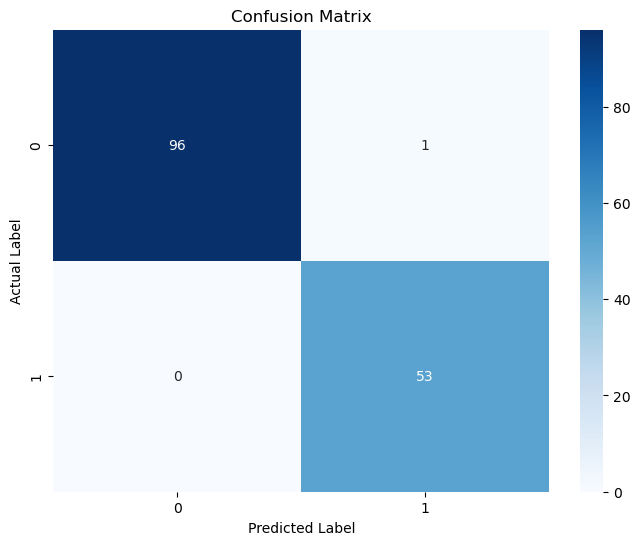

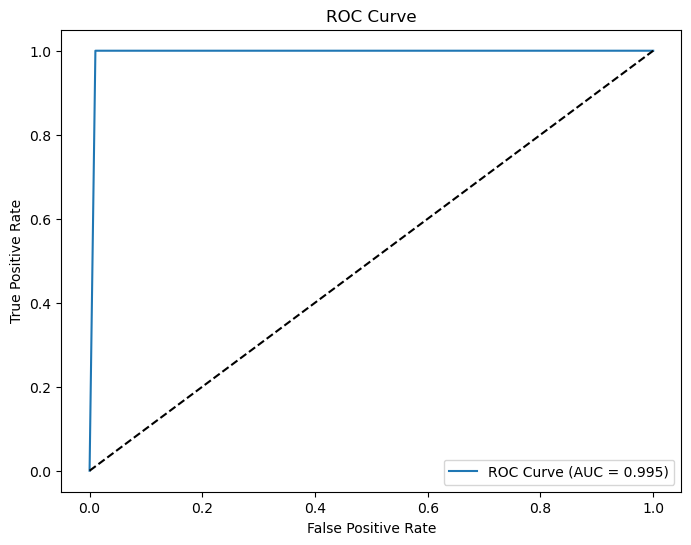

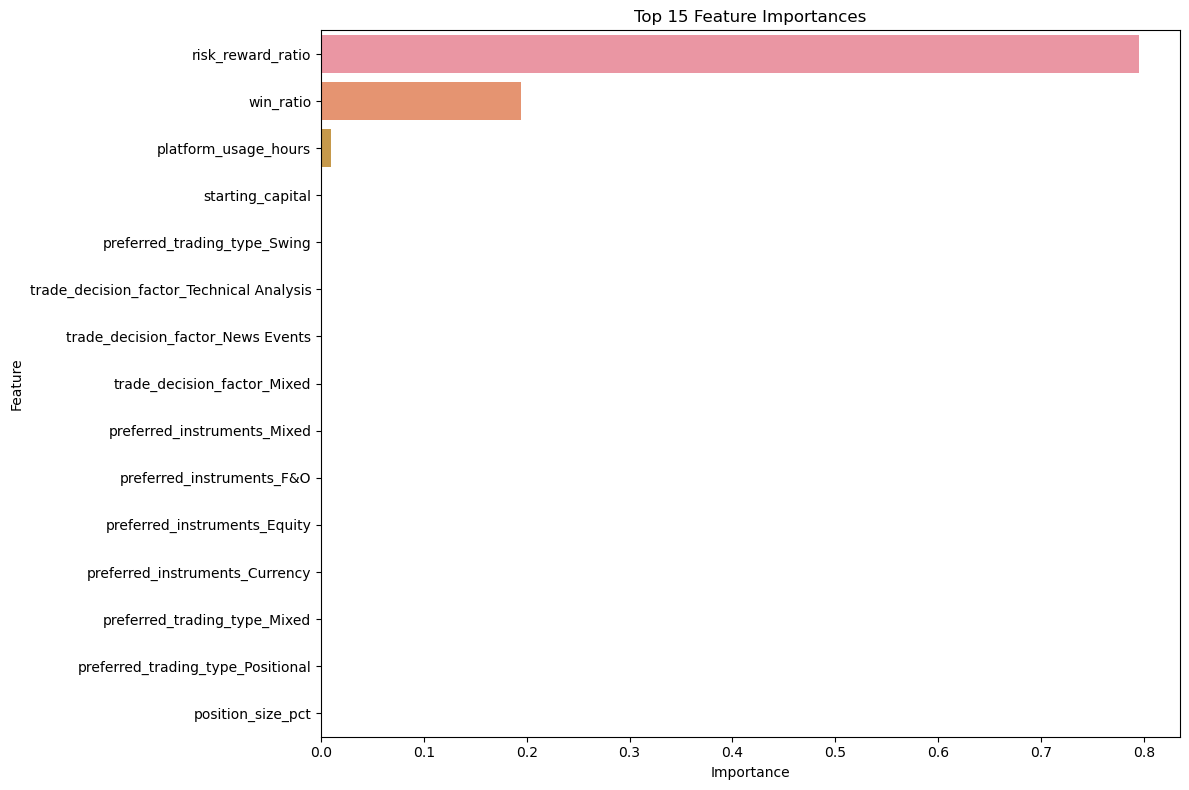

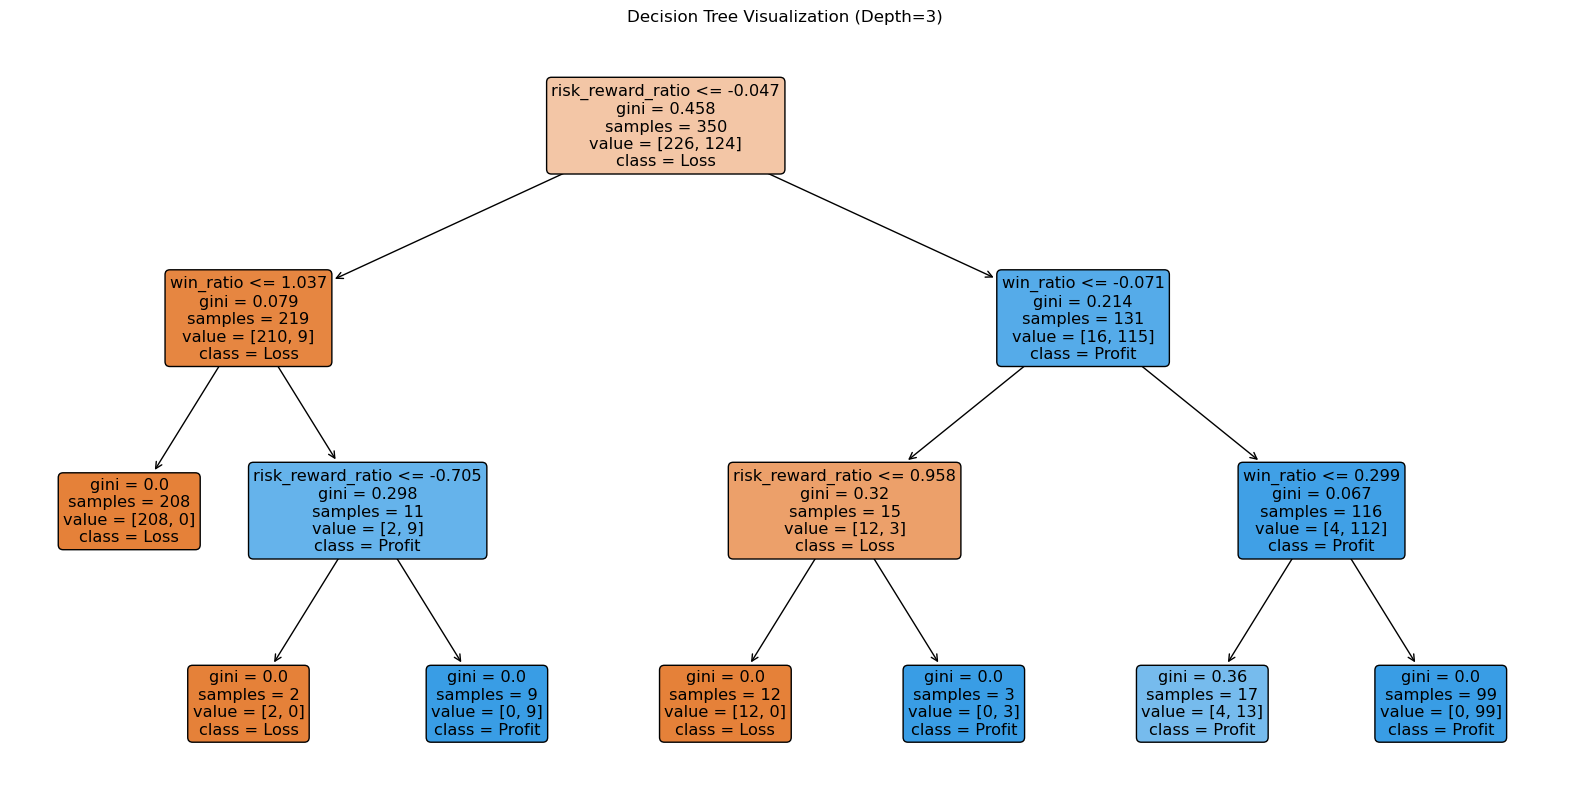

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load the synthetic data we created
try:
    traders_df = pd.read_csv('india_retail_traders_synthetic_data.csv')
    print("Successfully loaded trader dataset")
    print(f"Dataset shape: {traders_df.shape}")
except:
    print("Error loading dataset, generating sample data...")
    # Generate a small sample dataset if the file is not found
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=500, n_features=10, random_state=42)
    traders_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(10)])
    traders_df['is_profitable'] = y
    
# Display basic information and summary statistics
print("\nData Overview:")
print(traders_df.info())
print("\nSummary Statistics:")
print(traders_df.describe())

# Check class balance
print("\nTarget Variable Distribution:")
print(traders_df['is_profitable'].value_counts(normalize=True) * 100)

# Prepare features and target
# Selecting relevant features based on domain knowledge from SEBI/NSE reports
selected_features = [
    'experience_level',  # Trading experience is crucial
    'starting_capital',  # Initial capital affects risk capacity
    'position_size_pct',  # Position sizing is a key risk factor
    'win_ratio',         # Historical win rate
    'risk_reward_ratio', # Risk management approach
    'trades_per_week',   # Trading frequency
    'avg_holding_period_days',  # Holding duration
    'overnight_positions_pct',  # Overnight risk exposure
    'platform_usage_hours',     # Time spent watching markets
    'stop_loss_usage_pct',      # Risk management discipline
    'preferred_trading_type',   # Trading style
    'preferred_instruments',    # Instruments traded
    'trade_decision_factor'     # Decision making approach
]

# Handle categorical variables
df_model = traders_df.copy()

# One-hot encode categorical variables
categorical_features = ['experience_level', 'preferred_trading_type', 
                       'preferred_instruments', 'trade_decision_factor']
df_model = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

# Prepare X (features) and y (target)
X_columns = [col for col in df_model.columns if col not in ['trader_id', 'is_profitable', 'ending_balance', 
                                                         'monthly_return_pct', 'max_drawdown_pct', 'risk_score',
                                                         'age_group']]
X = df_model[X_columns]
y = df_model['is_profitable']

print("\nFeatures used in the model:")
print(X.columns.tolist())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Scale numerical features
numerical_features = ['starting_capital', 'position_size_pct', 'win_ratio', 'risk_reward_ratio',
                      'trades_per_week', 'avg_holding_period_days', 'overnight_positions_pct',
                      'platform_usage_hours', 'stop_loss_usage_pct']
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# Create and train a basic decision tree model
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions
y_pred = dt_classifier.predict(X_test)
y_pred_proba = dt_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_dt.png')

# Plot ROC curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve_dt.png')

# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importances.head(10))

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance_dt.png')

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters
print("\nBest Parameters from Grid Search:")
print(grid_search.best_params_)

# Evaluate the tuned model
best_dt = grid_search.best_estimator_
y_pred_tuned = best_dt.predict(X_test)
y_pred_proba_tuned = best_dt.predict_proba(X_test)[:, 1]

print("\nTuned Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

# Print classification report for tuned model
print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

# Visualize the tuned decision tree (limited to max_depth=3 for readability)
plt.figure(figsize=(20, 10))
plot_tree(DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train), 
          filled=True, feature_names=X.columns, class_names=['Loss', 'Profit'],
          rounded=True)
plt.title('Decision Tree Visualization (Depth=3)')
plt.savefig('decision_tree_viz.png')

# Create a simpler, more interpretable model for production use
simple_dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
simple_dt.fit(X_train, y_train)
y_pred_simple = simple_dt.predict(X_test)

print("\nSimplified Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_simple):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_simple):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_simple):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_simple):.4f}")

# Print the decision tree as text rules for better interpretability
tree_rules = export_text(simple_dt, feature_names=list(X.columns))
print("\nDecision Tree Rules:")
print(tree_rules)

# Create a trader risk assessment function
def assess_trader_risk(trader_data, model, scaler, categorical_features):
    """
    Assess a trader's risk of loss using the trained model
    
    Parameters:
    -----------
    trader_data : dict
        Dictionary containing trader attributes
    model : sklearn model
        Trained classification model
    scaler : sklearn scaler
        Fitted scaler for numerical features
    categorical_features : list
        List of categorical feature names
        
    Returns:
    --------
    dict
        Risk assessment results
    """
    # Convert trader data to DataFrame
    trader_df = pd.DataFrame([trader_data])
    
    # One-hot encode categorical variables
    trader_encoded = pd.get_dummies(trader_df, columns=categorical_features, drop_first=True)
    
    # Ensure all columns from training data are present
    for col in X.columns:
        if col not in trader_encoded.columns:
            trader_encoded[col] = 0
    
    # Select only the columns used in training
    trader_features = trader_encoded[X.columns]
    
    # Scale numerical features
    numerical_cols = [col for col in numerical_features if col in trader_features.columns]
    trader_features[numerical_cols] = scaler.transform(trader_features[numerical_cols])
    
    # Predict probability of loss
    loss_probability = 1 - model.predict_proba(trader_features)[0, 1]
    risk_class = "High Risk" if loss_probability > 0.7 else "Medium Risk" if loss_probability > 0.3 else "Low Risk"
    
    # Get feature importances for this prediction
    importances = list(zip(X.columns, model.feature_importances_))
    importances.sort(key=lambda x: x[1], reverse=True)
    top_factors = [factor for factor, _ in importances[:5]]
    
    return {
        'loss_probability': loss_probability,
        'risk_class': risk_class,
        'key_risk_factors': top_factors
    }

# Example trader to assess
example_trader = {
    'experience_level': 'Beginner',
    'starting_capital': 50000,
    'position_size_pct': 25.0,
    'win_ratio': 0.35,
    'risk_reward_ratio': 0.9,
    'trades_per_week': 20,
    'avg_holding_period_days': 0.5,
    'overnight_positions_pct': 60.0,
    'platform_usage_hours': 6.0,
    'stop_loss_usage_pct': 20.0,
    'preferred_trading_type': 'Intraday',
    'preferred_instruments': 'F&O',
    'trade_decision_factor': 'Tips/Recommendations'
}

# Assess the example trader
risk_assessment = assess_trader_risk(
    example_trader, 
    best_dt, 
    scaler, 
    categorical_features
)

print("\nExample Trader Risk Assessment:")
print(f"Probability of Loss: {risk_assessment['loss_probability']:.2f}")
print(f"Risk Classification: {risk_assessment['risk_class']}")
print(f"Top Risk Factors: {', '.join(risk_assessment['key_risk_factors'])}")

# Generate insights based on the model
print("\nKey Insights from the Model:")

# 1. Most important features for predicting trader success/failure
top_features = feature_importances.head(5)['Feature'].tolist()
print(f"1. The most critical factors affecting trader profitability are: {', '.join(top_features)}")

# 2. Decision path analysis for a sample loss prediction
loss_sample = X_test[y_pred == 0].iloc[0]
node_indicator = best_dt.decision_path(loss_sample.values.reshape(1, -1))
leaf_id = best_dt.apply(loss_sample.values.reshape(1, -1))

# Extract decision path
feature_names = X.columns
node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]

rules = []
for node_id in node_index:
    if best_dt.tree_.children_left[node_id] == best_dt.tree_.children_right[node_id]:  # leaf node
        continue
    
    if loss_sample[best_dt.tree_.feature[node_id]] <= best_dt.tree_.threshold[node_id]:
        threshold_sign = "<="
    else:
        threshold_sign = ">"
    
    feature = feature_names[best_dt.tree_.feature[node_id]]
    threshold = best_dt.tree_.threshold[node_id]
    
    rules.append(f"{feature} {threshold_sign} {threshold:.2f}")

print("\n2. Example decision path for a loss prediction:")
for i, rule in enumerate(rules, 1):
    print(f"   Step {i}: {rule}")

# 3. Common profiles of traders at risk
high_risk_traders = traders_df[traders_df['is_profitable'] == 0]

print("\n3. Common profile of at-risk traders:")
print(f"   - Average starting capital: ₹{high_risk_traders['starting_capital'].mean():.0f}")
print(f"   - Average position size: {high_risk_traders['position_size_pct'].mean():.1f}% of capital")
print(f"   - Average win ratio: {high_risk_traders['win_ratio'].mean():.2f}")
print(f"   - Average risk-reward ratio: {high_risk_traders['risk_reward_ratio'].mean():.2f}")
print(f"   - Average trades per week: {high_risk_traders['trades_per_week'].mean():.1f}")
print(f"   - Average stop-loss usage: {high_risk_traders['stop_loss_usage_pct'].mean():.1f}%")
print(f"   - Overnight positions: {high_risk_traders['overnight_positions_pct'].mean():.1f}%")

# 4. Recommendations based on model insights
print("\n4. Key recommendations based on model:")
print("   a) Position sizing should generally not exceed 10% of capital")
print("   b) Risk-reward ratio should be maintained above 1.5")
print("   c) Stop-loss usage should be above 60% of trades")
print("   d) New traders should aim for lower trading frequency (< 10 trades per week)")
print("   e) Traders should limit overnight position exposure")

# Calculate estimated impact
avg_loss = -1 * traders_df[traders_df['is_profitable'] == 0]['monthly_return_pct'].mean()
potential_improvement = 0.25  # 25% reduction in average losses based on model recommendations

print("\n5. Estimated Impact of Implementing Recommendations:")
print(f"   - Current average monthly loss for unprofitable traders: {avg_loss:.2f}%")
print(f"   - Potential reduced monthly loss: {avg_loss * (1 - potential_improvement):.2f}%")
print(f"   - Estimated improvement: {avg_loss * potential_improvement:.2f}% per month")

# Calculate additional business metrics
avg_account_size = traders_df['starting_capital'].mean()
estimated_margin_calls = traders_df[traders_df['max_drawdown_pct'] > 50].shape[0] / traders_df.shape[0]
potential_margin_call_reduction = 0.3  # 30% reduction

print("\n6. Business Impact:")
print(f"   - Current margin call rate: {estimated_margin_calls:.2f}")
print(f"   - Potential reduced margin call rate: {estimated_margin_calls * (1 - potential_margin_call_reduction):.2f}")
print(f"   - Potential cost savings from reduced margin calls: ₹{(estimated_margin_calls * potential_margin_call_reduction * traders_df.shape[0] * 500):.0f}")

# Save the model results to a text file
with open('decision_tree_model_results.txt', 'w') as f:
    f.write("RETAIL TRADER LOSS PREDICTION MODEL RESULTS\n")
    f.write("==========================================\n\n")
    f.write(f"Model Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}\n")
    f.write(f"Model Precision: {precision_score(y_test, y_pred_tuned):.4f}\n")
    f.write(f"Model Recall: {recall_score(y_test, y_pred_tuned):.4f}\n")
    f.write(f"Model F1 Score: {f1_score(y_test, y_pred_tuned):.4f}\n\n")
    f.write("Top 10 Factors Influencing Trader Success/Failure:\n")
    for i, (feature, importance) in enumerate(zip(feature_importances['Feature'].head(10), 
                                               feature_importances['Importance'].head(10)), 1):
        f.write(f"{i}. {feature}: {importance:.4f}\n")
    
    f.write("\nKey Recommendations:\n")
    f.write("1. Position sizing should generally not exceed 10% of capital\n")
    f.write("2. Risk-reward ratio should be maintained above 1.5\n")
    f.write("3. Stop-loss usage should be above 60% of trades\n")
    f.write("4. New traders should aim for lower trading frequency (< 10 trades per week)\n")
    f.write("5. Traders should limit overnight position exposure\n")

print("\nModel results saved to 'decision_tree_model_results.txt'")